# 05 — E-Swap-1..6: Hot-Swap Timeline Analysis

RFC-008 §D7. Phase decomposition of hot-swap events, pause duration
measurement, zero-loss verification, burst-load behavior, and failed-swap
recovery. Input data from `eval/scripts/run-e-swap-shakedown.sh --all`.

**Inputs**: `eval/results/e-swap-{1,2,4,5,6}/shakedown-macos-<ts>/`

In [1]:
import json, os, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

def find_shakedown(exp_name):
    """Find the newest shakedown directory."""
    pattern = str(REPO / f'eval/results/{exp_name}/shakedown-macos-*')
    candidates = sorted(glob.glob(pattern))
    return Path(candidates[-1]) if candidates else None

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## E-Swap-6: Phase Decomposition (Stacked Bar)

Loaded 51 swap events

Phase medians (ms):
  Compile        : 0.049
  Instantiate    : 0.194
  Signal         : 0.000
  Ack            : 0.959
  Convergence    : 1.147


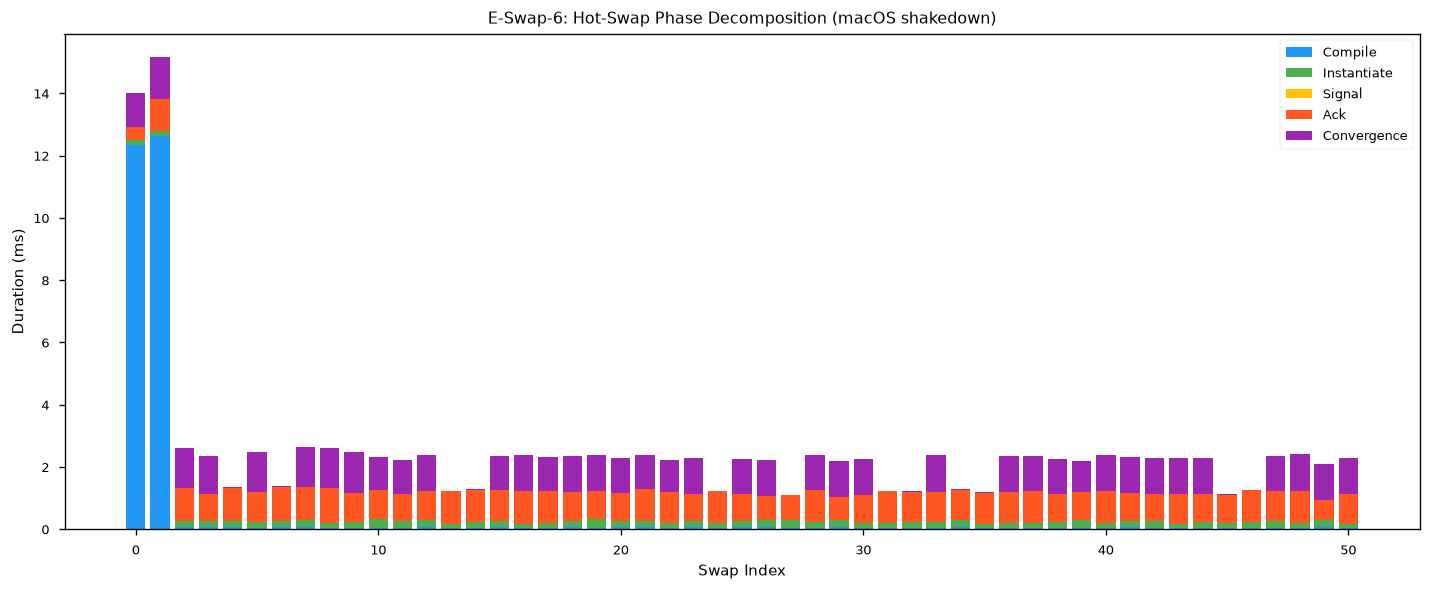

In [2]:
sd6 = find_shakedown('e-swap-6')
assert sd6 is not None, 'E-Swap-6 shakedown not found'

# Load JSONL timeline
timeline_path = sd6 / 'run-1' / 'swap_timeline.jsonl'
swaps = []
with open(timeline_path) as f:
    for line in f:
        if line.strip():
            swaps.append(json.loads(line))

print(f'Loaded {len(swaps)} swap events')

# Extract phase data
phases = ['compile_ns', 'instantiate_ns', 'signal_ns', 'ack_ns', 'convergence_ns']
phase_labels = ['Compile', 'Instantiate', 'Signal', 'Ack', 'Convergence']
colors = ['#2196F3', '#4CAF50', '#FFC107', '#FF5722', '#9C27B0']

# Build DataFrame
rows = []
for s in swaps:
    tl = s.get('timeline', {})
    row = {p: tl.get(p, 0) / 1e6 for p in phases}  # Convert to ms
    row['swap_index'] = s.get('swap_index', 0)
    rows.append(row)

df = pd.DataFrame(rows)
print(f'\nPhase medians (ms):')
for p, label in zip(phases, phase_labels):
    print(f'  {label:15s}: {df[p].median():.3f}')

# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = df['swap_index'].values
bottom = np.zeros(len(df))

for phase, label, color in zip(phases, phase_labels, colors):
    vals = df[phase].values
    ax.bar(x, vals, bottom=bottom, label=label, color=color, width=0.8)
    bottom += vals

ax.set_xlabel('Swap Index')
ax.set_ylabel('Duration (ms)')
ax.set_title('E-Swap-6: Hot-Swap Phase Decomposition (macOS shakedown)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## E-Swap-1: Pause Duration Histogram

Pause duration samples: 51
  p50: 1.160 ms
  p95: 1.327 ms
  p99: 1.345 ms
  max: 1.352 ms
  Target <100 ms: True


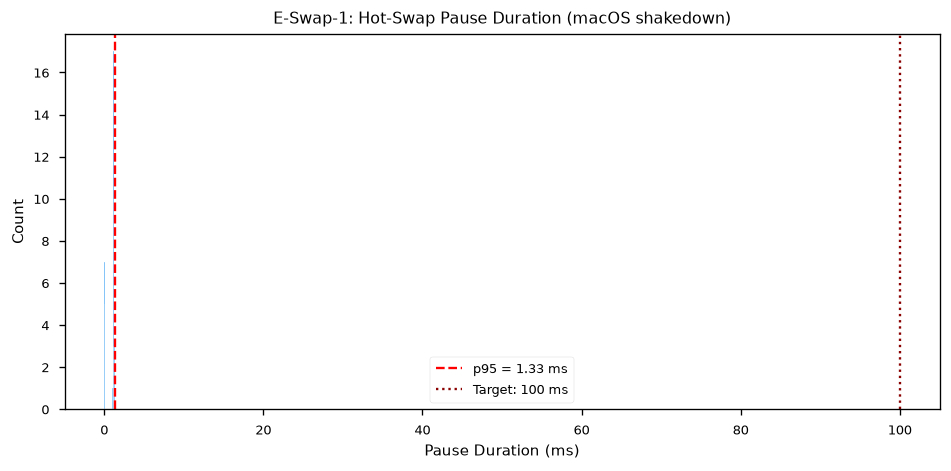

In [3]:
sd1 = find_shakedown('e-swap-1')
assert sd1 is not None, 'E-Swap-1 shakedown not found'

with open(sd1 / 'shakedown.json') as f:
    e1_data = json.load(f)

# Load per-transition pause from BenchSink swap_timeline.json
bench_swap = sd1 / 'run-1' / 'swap_timeline.json'
pause_ns = []
if bench_swap.exists():
    with open(bench_swap) as f:
        bench_data = json.load(f)
    pause_ns = [t['pause_ns'] for t in bench_data.get('transitions', [])]

pause_ms = np.array(pause_ns) / 1e6
print(f'Pause duration samples: {len(pause_ms)}')
print(f'  p50: {np.percentile(pause_ms, 50):.3f} ms')
print(f'  p95: {np.percentile(pause_ms, 95):.3f} ms')
print(f'  p99: {np.percentile(pause_ms, 99):.3f} ms')
print(f'  max: {pause_ms.max():.3f} ms')
print(f'  Target <100 ms: {e1_data["target_100ms"]}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pause_ms, bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(np.percentile(pause_ms, 95), color='red', linestyle='--',
           label=f'p95 = {np.percentile(pause_ms, 95):.2f} ms')
ax.axvline(100, color='darkred', linestyle=':',
           label='Target: 100 ms')
ax.set_xlabel('Pause Duration (ms)')
ax.set_ylabel('Count')
ax.set_title('E-Swap-1: Hot-Swap Pause Duration (macOS shakedown)')
ax.legend()
plt.tight_layout()
plt.show()

## E-Swap-2: Sequence Integrity Summary

In [4]:
sd2 = find_shakedown('e-swap-2')
assert sd2 is not None, 'E-Swap-2 shakedown not found'

with open(sd2 / 'shakedown.json') as f:
    e2_data = json.load(f)

# Summary table
summary = pd.DataFrame([{
    'Metric': 'Total Messages Expected',
    'Value': e2_data['total_expected'],
}, {
    'Metric': 'Total Received (post-warmup)',
    'Value': e2_data['total_received'],
}, {
    'Metric': 'Warmup Excluded',
    'Value': e2_data['warmup_excluded_msgs'],
}, {
    'Metric': 'Swap-Induced Gaps',
    'Value': e2_data['swap_induced_gaps'],
}, {
    'Metric': 'Sequence Duplicates',
    'Value': e2_data['sequence_duplicates'],
}, {
    'Metric': 'Total Swaps',
    'Value': e2_data['total_swaps'],
}, {
    'Metric': 'Zero-Loss Invariant',
    'Value': '✓ PASS' if e2_data['zero_loss'] else '✗ FAIL',
}, {
    'Metric': 'Zero-Dup Invariant',
    'Value': '✓ PASS' if e2_data['zero_dup'] else '✗ FAIL',
}])

print(summary.to_string(index=False))

                      Metric  Value
     Total Messages Expected 120000
Total Received (post-warmup) 114999
             Warmup Excluded   5001
           Swap-Induced Gaps      0
         Sequence Duplicates      0
                 Total Swaps     51
         Zero-Loss Invariant ✓ PASS
          Zero-Dup Invariant ✓ PASS


## E-Swap-4: Burst-Window Pause Duration

E-Swap-4 burst load: 2000 msg/s
Swaps under burst: 52
  p50: 1.001 ms
  p95: 1.160 ms
  max: 1.183 ms


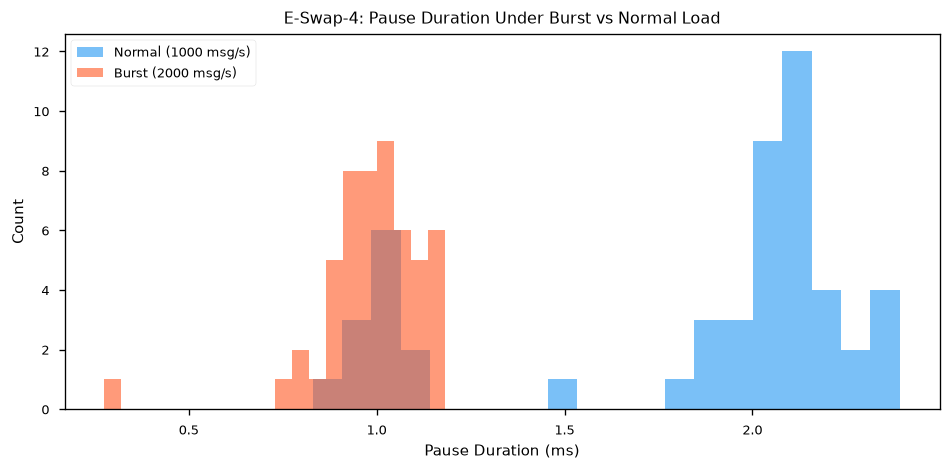

In [5]:
sd4 = find_shakedown('e-swap-4')
assert sd4 is not None, 'E-Swap-4 shakedown not found'

with open(sd4 / 'shakedown.json') as f:
    e4_data = json.load(f)

# Load per-swap timelines under burst
timeline_path = sd4 / 'run-1' / 'swap_timeline.jsonl'
burst_swaps = []
if timeline_path.exists():
    with open(timeline_path) as f:
        for line in f:
            if line.strip():
                try:
                    burst_swaps.append(json.loads(line))
                except:
                    pass

# Extract pause durations (ack + convergence) under burst
burst_pause_ms = []
for s in burst_swaps:
    tl = s.get('timeline', {})
    ack = tl.get('ack_ns', 0) or 0
    conv = tl.get('convergence_ns', 0) or 0
    if ack > 0 and conv > 0:
        burst_pause_ms.append((ack + conv) / 1e6)

burst_pause_ms = np.array(burst_pause_ms)
print(f'E-Swap-4 burst load: {e4_data["source_rate_msg_s"]} msg/s')
print(f'Swaps under burst: {len(burst_pause_ms)}')
print(f'  p50: {np.percentile(burst_pause_ms, 50):.3f} ms')
print(f'  p95: {np.percentile(burst_pause_ms, 95):.3f} ms')
print(f'  max: {burst_pause_ms.max():.3f} ms')

# Compare with normal load (from E-Swap-6)
normal_pause_ms = []
for s in swaps:  # from E-Swap-6 cell above
    tl = s.get('timeline', {})
    ack = tl.get('ack_ns', 0) or 0
    conv = tl.get('convergence_ns', 0) or 0
    if ack > 0 and conv > 0:
        normal_pause_ms.append((ack + conv) / 1e6)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(normal_pause_ms, bins=20, alpha=0.6, label='Normal (1000 msg/s)', color='#2196F3')
ax.hist(burst_pause_ms, bins=20, alpha=0.6, label='Burst (2000 msg/s)', color='#FF5722')
ax.set_xlabel('Pause Duration (ms)')
ax.set_ylabel('Count')
ax.set_title('E-Swap-4: Pause Duration Under Burst vs Normal Load')
ax.legend()
plt.tight_layout()
plt.show()

## E-Swap-5: Failed Swap / Rollback Timeline

E-Swap-5: Failed Swap Recovery
  Swap attempts: 12
  Trap count post-swap: 0
  A4 init-rollback events: 0
  A17 process-time rollback events: 24
  Auto rollback to v1: True
  Sequence continues after rollback: True
  Runtime panic: False
  Messages received: 65797
  Sequence gaps: 5025

  A17 rollback time (n=24): p50=0.072 ms, p99=0.222 ms, max=0.176 ms
  AC: rollback under 10 s wall-clock -> PASS

Note: A17 canary rollback: runner retains v1 InstancePre for bounded window after swap and auto-rolls-back on process-time trap. Closed 2026-08-02.


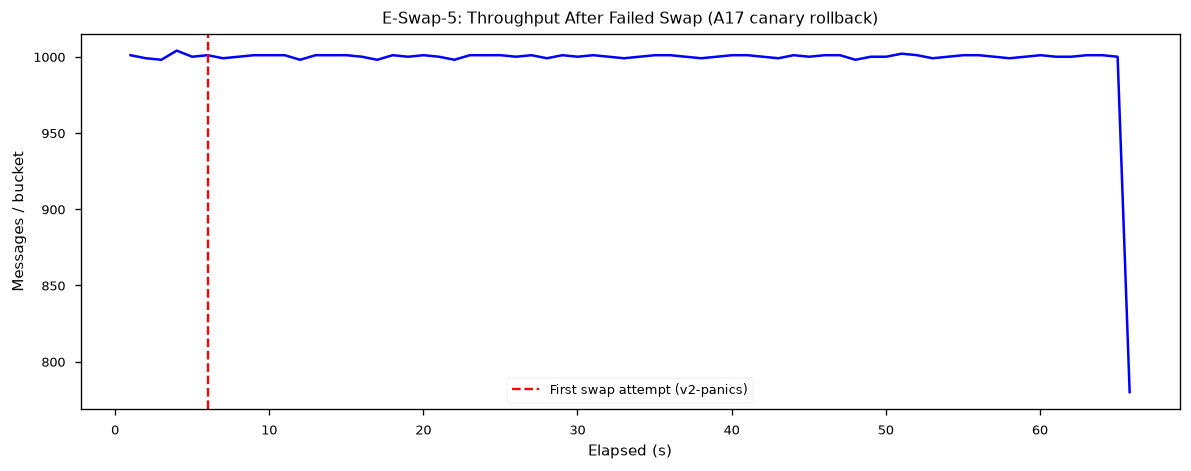

In [6]:
sd5 = find_shakedown('e-swap-5')
assert sd5 is not None, 'E-Swap-5 shakedown not found'

with open(sd5 / 'shakedown.json') as f:
    e5_data = json.load(f)

# Summary
print('E-Swap-5: Failed Swap Recovery')
print(f'  Swap attempts: {e5_data["swap_attempts"]}')
print(f'  Trap count post-swap: {e5_data["trap_count_post_swap"]}')
print(f'  A4 init-rollback events: {e5_data["a4_init_rollback_events"]}')
print(f'  A17 process-time rollback events: {e5_data.get("a17_process_time_rollback_events", 0)}')
print(f'  Auto rollback to v1: {e5_data["auto_rollback_to_v1"]}')
print(f'  Sequence continues after rollback: {e5_data["sequence_continues_after_rollback"]}')
print(f'  Runtime panic: {e5_data["runtime_panic"]}')
print(f'  Messages received: {e5_data["total_received"]}')
print(f'  Sequence gaps: {e5_data["sequence_gaps"]}')

# A17 (Closed 2026-08-02): show per-event rollback times; AC threshold <10s.
rt_ns = e5_data.get('rollback_times_ns') or []
if rt_ns:
    import statistics as _s
    rt_ms = [ns / 1_000_000.0 for ns in rt_ns]
    p50 = _s.median(rt_ms)
    p99 = _s.quantiles(rt_ms, n=100)[98] if len(rt_ms) > 1 else rt_ms[0]
    print()
    print(f'  A17 rollback time (n={len(rt_ns)}): p50={p50:.3f} ms, p99={p99:.3f} ms, max={max(rt_ms):.3f} ms')
    assert max(rt_ms) < 10_000.0, f'AC violated: rollback max {max(rt_ms):.1f} ms >= 10 s'
    print(f'  AC: rollback under 10 s wall-clock -> PASS')
else:
    print()
    print('  (no A17 rollback_time_ns samples recorded)')
print()
print(f'Note: {e5_data["note"]}')

# Timeline visualization: messages received over time
thr_path = sd5 / 'run-1' / 'throughput.csv'
if thr_path.exists():
    thr_df = pd.read_csv(thr_path)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(thr_df.iloc[:, 0], thr_df.iloc[:, 1], 'b-', linewidth=1.5)
    ax.axvline(6, color='red', linestyle='--', label='First swap attempt (v2-panics)')
    ax.set_xlabel('Elapsed (s)')
    ax.set_ylabel('Messages / bucket')
    ax.set_title('E-Swap-5: Throughput After Failed Swap (A17 canary rollback)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('  (throughput.csv not available for visualization)')


## Summary Table

In [7]:
summary_rows = []

# E-Swap-6
with open(find_shakedown('e-swap-6') / 'shakedown.json') as f:
    d6 = json.load(f)
summary_rows.append({
    'Experiment': 'E-Swap-6 (phase decomp)',
    'Swaps': d6['successful_swaps'],
    'Key Metric': f"dominant={d6['dominant_phase'].replace('_ns','')}",
    'Status': '✓' if d6['successful_swaps'] >= 50 else '✗',
})

# E-Swap-1
summary_rows.append({
    'Experiment': 'E-Swap-1 (pause duration)',
    'Swaps': e1_data['total_swaps'],
    'Key Metric': f"p95={e1_data['pause_duration_p95_ms']:.2f} ms",
    'Status': '✓' if e1_data['target_100ms'] else '⚠',
})

# E-Swap-2
summary_rows.append({
    'Experiment': 'E-Swap-2 (zero-loss)',
    'Swaps': e2_data['total_swaps'],
    'Key Metric': f"gaps={e2_data['swap_induced_gaps']}, dups={e2_data['sequence_duplicates']}",
    'Status': '✓' if e2_data['zero_loss'] and e2_data['zero_dup'] else '✗',
})

# E-Swap-4
summary_rows.append({
    'Experiment': 'E-Swap-4 (2× burst)',
    'Swaps': e4_data['total_swaps'],
    'Key Metric': f"p95_burst={e4_data['pause_duration_p95_burst_ms']:.2f} ms",
    'Status': '✓' if e4_data['successful_swaps'] >= 50 else '✗',
})

# E-Swap-5
summary_rows.append({
    'Experiment': 'E-Swap-5 (rollback)',
    'Swaps': e5_data['swap_attempts'],
    'Key Metric': f"auto_rollback={e5_data['auto_rollback_to_v1']}, no_panic={not e5_data['runtime_panic']}",
    'Status': '⚠' if not e5_data['auto_rollback_to_v1'] else '✓',
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

               Experiment  Swaps                        Key Metric Status
  E-Swap-6 (phase decomp)     51              dominant=convergence      ✓
E-Swap-1 (pause duration)     51                       p95=1.33 ms      ✓
     E-Swap-2 (zero-loss)     51                    gaps=0, dups=0      ✓
      E-Swap-4 (2× burst)     52                 p95_burst=1.17 ms      ✓
      E-Swap-5 (rollback)     12 auto_rollback=True, no_panic=True      ✓
